In [1]:
### Imports

import numpy as np
import torch
from database import open_feather, RENAL_DB_PATH, prepare_database, get_tabpfn_arrays, scale_df_data, compare_distributions, plot_deaths_distribution
from sae import train_sae_model
from tabpfn_model import fit_dr_tabpfn, walkforward_evaluate_tabpfn, TabPFNEvalConfig, load_or_extract_embeddings, EmbeddingExtractConfig, scale_embeddings, temporal_test_subsplits
from decision_tree import train_binary_trees, get_rules_forced
from tcav import train_cavs_from_rules, get_model_gradients, get_tcav_scores, run_feature_association_dual_split, run_sparse_readout_dual_split, get_significant_concepts
from filepaths import get_env_path
from pickle import dump, load
import os
import pandas as pd
from tabpfn import TabPFNClassifier
from results import cid10_dict, translate_event_names
import matplotlib.pyplot as plt
from sae_compare import run_sae_random_comparison, plot_run_results, calculate_concept_correlation_drift, plotar_termometro_drift
from instance_selection import infer_with_selected_instances
from dotenv import load_dotenv
load_dotenv()

/home/joaomarcostomaz/SAE-TCAV-extension/SAE-TCAV/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


False

In [2]:
### Tratamento de dados

PREPARED_DB_PATH = get_env_path('data/renal/prep.pkl')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
df = open_feather(RENAL_DB_PATH)
if not os.path.exists(PREPARED_DB_PATH):
    prep_out = prepare_database(df=df)
    tabpfn_arrays = get_tabpfn_arrays(prep_out)
    with open(PREPARED_DB_PATH, 'wb') as f:
        dump(prep_out, f)
else:
    with open(PREPARED_DB_PATH, 'rb') as f:
        prep_out = load(f)
        tabpfn_arrays = get_tabpfn_arrays(prep_out)

train_rows = prep_out['train_rows']
test_rows = prep_out['test_rows']
top_k_events = prep_out['top_k_events']
cid = cid10_dict()

X_train_np = tabpfn_arrays['X_train']
y_train_np = tabpfn_arrays['y_train']
years_train_np = tabpfn_arrays['years_train']

X_test_np = tabpfn_arrays['X_test']
y_test_np = tabpfn_arrays['y_test']
years_test_np = tabpfn_arrays['years_test']


feature_cols = list(np.asarray(top_k_events))
X_train_df = train_rows[feature_cols].copy()
X_test_df = test_rows[feature_cols].copy()

print(f'years_train: {years_train_np.shape}')
print(f'years_test: {years_test_np.shape}')
print("train_rows:", train_rows.shape)
print("test_rows :", test_rows.shape)
print("n top_k_events:", len(top_k_events))
print("train_years:", np.unique(years_train_np))
print("test_years :", np.unique(years_test_np))
print("X_train_np:", X_train_np.shape)
print("y_train_np:", y_train_np.shape, "| pos_ratio:", y_train_np.mean())

years_train: (9219,)
years_test: (21961,)
train_rows: (9219, 503)
test_rows : (21961, 503)
n top_k_events: 500
train_years: [1998 1999 2000 2001 2002 2003 2004 2005 2006]
test_years : [2007 2008 2009 2010 2011 2012 2013 2014 2015]
X_train_np: (9219, 500)
y_train_np: (9219,) | pos_ratio: 0.1740969736413928


In [3]:
### Avaliação de drift nos dados e (opcional) selecão de features estáveis

cut_features = False
data_shift_df, features_to_keep, features_to_keep_name = compare_distributions(x_i=X_train_np, x_j=X_test_np, top_k_events=top_k_events)

X_train_start = train_rows[train_rows['year'] == 2000][feature_cols].to_numpy()
X_train_end = train_rows[train_rows['year'] == max(years_train_np)][feature_cols].to_numpy()

data_shift_train, _, _ = compare_distributions(X_train_start, X_train_end, top_k_events)

X_test_start = test_rows[test_rows['year'] == min(years_test_np)][feature_cols].to_numpy()
X_test_end = test_rows[test_rows['year'] == max(years_test_np)][feature_cols].to_numpy()

data_shift_test, _, _ = compare_distributions(X_test_start, X_test_end, top_k_events)

data_shift_df.to_csv('stats/data_shift.csv')
data_shift_train.to_csv('stats/data_shift_train.csv')
data_shift_test.to_csv('stats/data_shift_test.csv')

if not cut_features:
    features_to_keep = np.ones(len(top_k_events), dtype=bool)
    features_to_keep_name = top_k_events

X_train_np = X_train_np[:, features_to_keep]
X_test_np = X_test_np[:, features_to_keep]

train_rows = train_rows[features_to_keep_name + ['patient_id', 'year', 'DEATH']]
test_rows = test_rows[features_to_keep_name + ['patient_id', 'year', 'DEATH']]

/home/joaomarcostomaz/SAE-TCAV-extension/SAE-TCAV/database.py:377: RuntimeWarning: divide by zero encountered in scalar divide
  'Mean ratio': max(mean_i[idx], mean_j[idx]) / min(mean_i[idx], mean_j[idx]),
/home/joaomarcostomaz/SAE-TCAV-extension/SAE-TCAV/database.py:378: RuntimeWarning: divide by zero encountered in scalar divide
  'Std ratio': max(std_i[idx], std_j[idx]) / min(std_i[idx], std_j[idx]),
/home/joaomarcostomaz/SAE-TCAV-extension/SAE-TCAV/.venv/lib/python3.11/site-packages/scipy/stats/_morestats.py:3057: RuntimeWarning: invalid value encountered in scalar divide
  W = numer / denom
/home/joaomarcostomaz/SAE-TCAV-extension/SAE-TCAV/database.py:377: RuntimeWarning: invalid value encountered in scalar divide
  'Mean ratio': max(mean_i[idx], mean_j[idx]) / min(mean_i[idx], mean_j[idx]),
/home/joaomarcostomaz/SAE-TCAV-extension/SAE-TCAV/database.py:378: RuntimeWarning: invalid value encountered in scalar divide
  'Std ratio': max(std_i[idx], std_j[idx]) / min(std_i[idx], std_j

In [4]:
### Fit + avaliação de desempenho do TabPFN

eval_cfg = TabPFNEvalConfig()
fit_out = fit_dr_tabpfn(X_train_np, y_train_np, years_train_np, eval_cfg)

drift_model: TabPFNClassifier = fit_out["model"]
model_add_x_device = fit_out["model_add_x_device"]
example_add_shape = fit_out["example_add_shape"]

print(f"Fit time: {fit_out['fit_time_sec']:.2f}s")
print("additional_x device:", model_add_x_device)
print("example_add_shape:", example_add_shape)

wf = walkforward_evaluate_tabpfn(
    drift_model=drift_model,
    test_rows=test_rows,
    top_k_events=top_k_events,
    train_years=years_train_np,
    model_add_x_device=model_add_x_device,
    batch_size_predict=512,
    example_add_shape=example_add_shape,
    use_cache=True
)

results_per_year = wf["results_per_year"]
year_to_domain_combined = wf["year_to_domain_combined"]
test_rows_checked = wf["test_rows_checked"]

results_per_year_df = pd.DataFrame(results_per_year)
results_df = pd.DataFrame(results_per_year).sort_values("year").reset_index(drop=True)
print(results_df)

Initialized decoder for standard with (None, 10)  and nout 10
Fit time: 0.37s
additional_x device: cpu
example_add_shape: (9219, 1, 1)
Carregando resultados do arquivo salvo
Carregando resultados do arquivo salvo
Carregando resultados do arquivo salvo
Carregando resultados do arquivo salvo
Carregando resultados do arquivo salvo
Carregando resultados do arquivo salvo
Carregando resultados do arquivo salvo
Carregando resultados do arquivo salvo
Carregando resultados do arquivo salvo
   year  n_samples  n_deaths  f1_macro    f1_pos  infer_time_sec
0  2007       1892       143  0.627652  0.321429       22.060546
1  2008       2401       179  0.648164  0.366667       27.094695
2  2009       2499       219  0.668945  0.406910       27.105881
3  2010       2600       216  0.632840  0.343066       32.375351
4  2011       2526       258  0.618444  0.320721       27.116339
5  2012       2536       215  0.599490  0.280156       27.098205
6  2013       2586       191  0.608449  0.294118       32.3

In [5]:
### Extração de embeddings do TabPFN

emb_cfg = EmbeddingExtractConfig()
emb_cfg.use_cache = True
emb_out = load_or_extract_embeddings(
    model=drift_model,
    X_train_np=X_train_np,
    X_test_np=X_test_np,
    years_train=years_train_np,
    years_test=years_test_np,
    year_to_domain_map=year_to_domain_combined,
    embeddings_dir=None,
    cfg=emb_cfg,
    device=model_add_x_device,
    example_add_shape=example_add_shape,
)

train_emb = emb_out['train_emb_flat'].astype(np.float32)
test_emb = emb_out['test_emb_flat'].astype(np.float32)
train_emb_scaled, test_emb_scaled, scaler_emb = scale_embeddings(train_emb, test_emb, fit_test=False)

models/tabpfn/dr_tabpfn_train_emb.npy models/tabpfn/dr_tabpfn_test_emb.npy


Carregando grads de models/tcav/grads_2007.pkl
Carregando grads de models/tcav/grads_2008.pkl
Carregando grads de models/tcav/grads_2009.pkl
failed to transform feature with error ValueError("Input X contains infinity or a value too large for dtype('float32').") skipping
Carregando grads de models/tcav/grads_2010.pkl
Carregando grads de models/tcav/grads_2011.pkl
Carregando grads de models/tcav/grads_2012.pkl
Carregando grads de models/tcav/grads_2013.pkl
Carregando grads de models/tcav/grads_2014.pkl
Carregando grads de models/tcav/grads_2015.pkl
      mean_cos_sim  mean_active  mean_mse  mean_survival_rate  mean_f1_macro  \
dist                                                                           
0         1.000000     8.410306  0.013690            1.000000       0.563773   
1         0.430223    24.328993  0.044931            0.903769       0.545005   
2         0.358908    34.181314  0.095812            0.860952       0.533302   
3         0.323915    40.178346  0.152020     

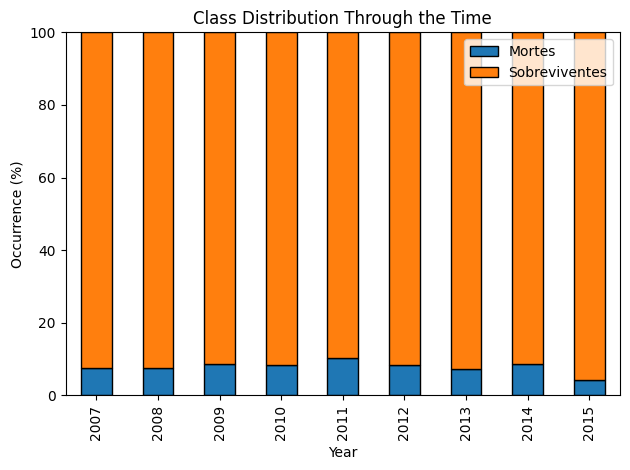

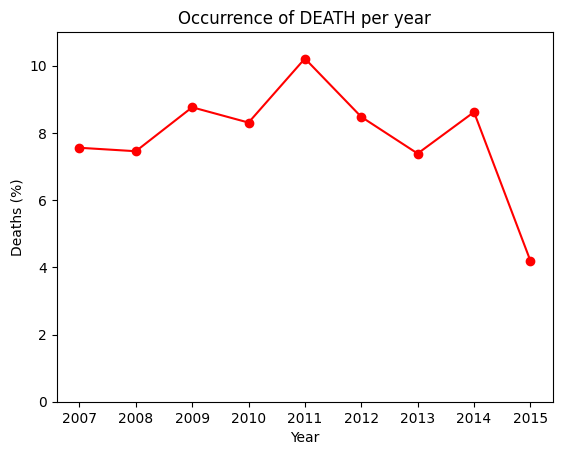

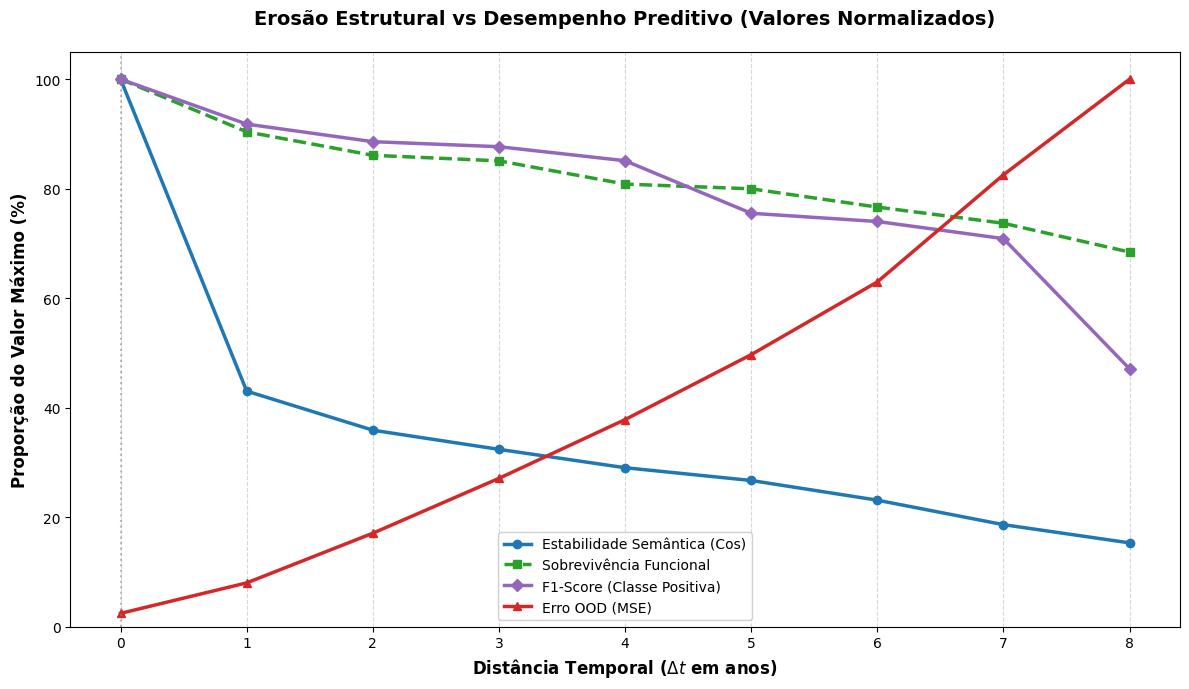

In [6]:
### Análise de drift de conceitos x degradação do modelo

plot_deaths_distribution(results_per_year)

full_df, dist_df = calculate_concept_correlation_drift(
    X_test_df=test_rows,
    test_embs=test_emb,
    test_years_np=years_test_np,
    features=feature_cols,
    alpha=1.0,
    undersample=True
)
plotar_termometro_drift(dist_df)

In [7]:
### Teste do TabPFN com seleção de contexto

test_indices = range(0, len(test_rows))
np.random.seed(42)
infer_indices = np.random.choice(test_indices, size=50, replace=False)
X_infer_np = X_test_np[infer_indices, :]
y_infer_np = y_test_np[infer_indices]
years_infer_np = years_test_np[infer_indices]
data = infer_with_selected_instances(
    base_model=drift_model,
    base_sae=train_sae_model(inputs=torch.tensor(train_emb_scaled, dtype=torch.float32), save_data=False, use_cache=False, alpha=1.0),
    X_train_np=X_train_np,
    years_train_np=years_train_np,
    y_train_np=y_train_np,
    train_embs=train_emb_scaled,
    X_infer_np=X_infer_np,
    y_infer_np=y_infer_np,
    years_infer_np=years_infer_np,
    emb_scaler=scaler_emb,
    add_x_device=model_add_x_device,
    add_x_shape=example_add_shape
)
for key, val in data.items():
    print(f'{key}: {val}')

preds_prob: [[0.86877733 0.13122272]
 [0.7079434  0.2920566 ]
 [0.74745214 0.2525479 ]
 [0.55296886 0.44703114]
 [0.6399361  0.3600639 ]
 [0.7246971  0.27530286]
 [0.71329844 0.28670153]
 [0.65626675 0.34373322]
 [0.852117   0.14788303]
 [0.75112116 0.24887887]
 [0.7772999  0.22270015]
 [0.6793678  0.3206322 ]
 [0.72121996 0.27878007]
 [0.376725   0.623275  ]
 [0.8226329  0.17736715]
 [0.61457396 0.38542604]
 [0.8142499  0.18575017]
 [0.43846458 0.5615354 ]
 [0.88873726 0.11126268]
 [0.8422874  0.15771256]
 [0.67557436 0.32442564]
 [0.8106122  0.18938778]
 [0.7901707  0.20982926]
 [0.6836073  0.31639275]
 [0.7630917  0.23690833]
 [0.6567561  0.34324393]
 [0.84142065 0.1585793 ]
 [0.80488354 0.19511648]
 [0.7746592  0.22534081]
 [0.567404   0.43259603]
 [0.6659901  0.3340099 ]
 [0.77428013 0.22571991]
 [0.8542914  0.14570862]
 [0.673669   0.32633108]
 [0.6626024  0.33739758]
 [0.34275484 0.65724516]
 [0.7894502  0.21054976]
 [0.7894502  0.21054976]
 [0.74291945 0.2570806 ]
 [0.76815397 

In [8]:
### Scaling e split dos dados

scaler, X_train_df_norm, X_test_df_norm = scale_df_data(
    X_train_df, X_test_df, feature_cols
)

print(f'X_train_df_norm: {X_train_df.shape}')
print(f'X_test_df_norm : {X_test_df.shape}')

y_test = (test_rows["DEATH"] > 0).astype(int).to_numpy(copy=True)
split_idx = temporal_test_subsplits(
    y_test,
    42
)

idx_test_discover = split_idx["idx_test_discover"]
idx_test_cav_train = split_idx["idx_test_cav_train"]
idx_test_tcav_eval = split_idx["idx_test_tcav_eval"]
idx_test_held_out = split_idx["idx_test_held_out"]

print("Discovery :", len(idx_test_discover), f"({len(idx_test_discover) / len(y_test):.1%})")
print("CAV Train :", len(idx_test_cav_train), f"({len(idx_test_cav_train) / len(y_test):.1%})")
print("TCAV Eval :", len(idx_test_tcav_eval), f"({len(idx_test_tcav_eval) / len(y_test):.1%})")
print("Held-out  :", len(idx_test_held_out), f"({len(idx_test_held_out) / len(y_test):.1%})")

y_test_discover = y_test[idx_test_discover]
y_test_cav_train = y_test[idx_test_cav_train]
y_test_tcav_eval = y_test[idx_test_tcav_eval]
y_test_held_out = y_test[idx_test_held_out]

years_test_discover = years_test_np[idx_test_discover]
years_test_cav_train = years_test_np[idx_test_cav_train]
years_test_tcav_eval = years_test_np[idx_test_tcav_eval]
years_test_held_out = years_test_np[idx_test_held_out]

emb_tcav_eval = test_emb_scaled[idx_test_tcav_eval]
emb_discovery = test_emb_scaled[idx_test_discover]

X_train_df_norm: (9219, 500)
X_test_df_norm : (21961, 500)
Discovery : 7247 (33.0%)
CAV Train : 7357 (33.5%)
TCAV Eval : 3678 (16.7%)
Held-out  : 3679 (16.8%)


Training 14 ReLU SAEs with Alpha = 1.0, Scaling Factor = 1.5
Salvando grafico em stats/sae/ReLU/good_pairs_cos_sim[Alpha=1.0,scale=1.5].png


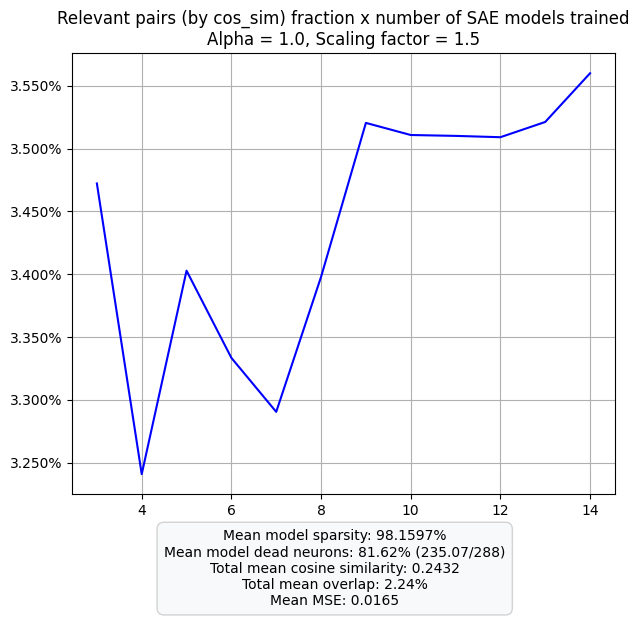

In [9]:
### Análise de retenção de conceitos do SAE em execuções aleatórias

inputs = emb_discovery
pair_criteria = 'cos_sim'
model_type = 'ReLU'
model_n = range(3, 15)
alphas = [1.0]
ks = [8]
scaling_factors = [1.5]

res, model_res, full_pair_df, sae_list = run_sae_random_comparison(
    model_nums=model_n,
    hyper_params=alphas if model_type == 'ReLU' else ks,
    embs=inputs,
    scaling_factors=scaling_factors,
    model_type=model_type,
    pair_criteria=pair_criteria,
)
pd.set_option('display.max_rows', 20)
full_pair_df['is_relevant_pair'] = full_pair_df[pair_criteria] >= 0.7
original_sae_df = full_pair_df[full_pair_df['sae_i_idx'] == 0].copy()

stats_by_concept = original_sae_df.groupby('original_concept').agg(
    survival_rate=('is_relevant_pair', 'mean'),
    mean_cos_sim=('cos_sim', 'mean'),
    mean_overlap=('overlap', 'mean')
).reset_index().sort_values('survival_rate', ascending=False)

surviving_concepts = stats_by_concept[stats_by_concept['survival_rate'] > 0.0]

pair_sae_idx = 1
original_sae_first_pairing_df = original_sae_df[original_sae_df['sae_j_idx'] == pair_sae_idx].copy()

first_pairing_survivors = original_sae_first_pairing_df[original_sae_first_pairing_df['is_relevant_pair'] == True]
original_survivors = first_pairing_survivors['original_concept'].tolist()
pairs = first_pairing_survivors['best_pair'].tolist()

with open(f'stats/concepts/surviving_concepts_{model_type}_sae.pkl', 'wb') as out:
    dump(surviving_concepts, out)
if model_type == 'ReLU':
    for alpha in alphas:
        plot_run_results(full_results=res, model_results=model_res, hyper_param=alpha,
                        scaling_factors=scaling_factors, model_n=model_n, pair_criteria=pair_criteria, model_type=model_type)
if model_type == 'TopK':
    for k in ks:
        plot_run_results(full_results=res, model_results=model_res, hyper_param=k,
                        scaling_factors=scaling_factors, model_n=model_n, pair_criteria=pair_criteria, model_type=model_type)

codes_train_tensor = []
codes_test_tensor = []
for s in sae_list:
    model = s['model']
    if model_type == 'TopK':
        sae_codes_train = model.encode(x=torch.tensor(inputs))[1].cpu().detach().numpy()
        sae_codes_test = model.encode(torch.tensor(test_emb_scaled[idx_test_cav_train]))[1].cpu().detach().numpy()
    else:
        sae_codes_train = model.encode(x=torch.tensor(inputs)).cpu().detach().numpy()
        sae_codes_test = model.encode(torch.tensor(test_emb_scaled[idx_test_cav_train])).cpu().detach().numpy()

    codes_train_tensor.append(sae_codes_train)
    codes_test_tensor.append(sae_codes_test)

codes_train_tensor = np.asarray(codes_train_tensor, dtype=np.float32)
codes_test_tensor = np.asarray(codes_test_tensor, dtype=np.float32)

In [10]:
### SAE usado no pipeline

sae = sae_list[0]['model']
sae_codes_train = codes_train_tensor[0]
sae_codes_test = codes_test_tensor[0]

sparsity_level = (sae_codes_train <= 1e-5).mean()
active_per_sample = (sae_codes_train > 1e-5).sum(axis=1).mean()

print(f'SAE codes (discovery): {sae_codes_train.shape}')
print(f"SAE near-zero activations: {sparsity_level:.2%}")
print(f"SAE active neurons/sample: {active_per_sample:.2f} / {sae_codes_train.shape[1]}")
print(f"SAE mean abs activation: {np.abs(sae_codes_train).mean():.4f}")
print(f"SAE max activation: {sae_codes_train.max():.4f}")
print(f'SAE dead neurons: {np.all(sae_codes_train <= 1e-5, axis=0).sum().item()}')

SAE codes (discovery): (7247, 288)
SAE near-zero activations: 98.14%
SAE active neurons/sample: 5.36 / 288
SAE mean abs activation: 0.1236
SAE max activation: 29.8065
SAE dead neurons: 245


In [11]:
### Árvores de decisão

rng = np.random.default_rng(42)
model_device = next(sae.parameters()).device
n_cav = len(idx_test_cav_train)
idx_local = np.arange(n_cav)
idx_tree_train = rng.choice(idx_local, size=int(n_cav * 0.5), replace=False)
idx_cav_final_train = np.setdiff1d(idx_local, idx_tree_train)

embeddings_dt = sae_codes_test[idx_tree_train]
X_cav_train_df = test_rows_checked.iloc[idx_test_cav_train][feature_cols].reset_index(drop=True)
X_feat_tree_train = X_cav_train_df.iloc[idx_tree_train].copy().to_numpy()
X_cav_final_df = X_cav_train_df.iloc[idx_cav_final_train].reset_index(drop=True)

tree_rules = train_binary_trees(embeddings_dt, X_feat_tree_train, feature_cols, model_type=model_type)
best_p = max(tree_rules.keys(), key=lambda p: len(tree_rules[p]))
rules_df = pd.DataFrame(tree_rules[best_p])
print(rules_df)

   Factor                                               Rule Class  Precision  \
0      84  EVENT_C1DIALISE_HD >  13.50 AND EVENT_c2MED_ER...  True   1.000000   
1      93  EVENT_C1DIALISE_HD >  5.50 AND EVENT_C1DIALISE...  True   0.937500   
2     138  EVENT_C1DIALISE_HD >  0.50 AND EVENT_C1DIALISE...  True   1.000000   
3     163  EVENT_C1DIALISE_HD >  1.50 AND EVENT_C1DIALISE...  True   0.947368   

     Recall  Patients  Patients_concept  
0  0.292350       107               366  
1  0.297030        64               202  
2  0.497159       175               352  
3  0.362416        57               149  


In [12]:
### Geração de regras para conceitos estáveis

forced_rules = get_rules_forced(
    train_activations=embeddings_dt,
    X=X_feat_tree_train,
    surviving_concepts=original_survivors,
    tree_rules_df=rules_df,
    perc=best_p, feature_names=feature_cols, model_type=model_type
)

original_concept_rules = pd.DataFrame(forced_rules)[['Factor', 'Rule', 'Precision', 'Recall']]
original_concept_rules = original_concept_rules.rename(columns={'Factor': 'original_concept', 'Rule': 'original_rule', 'Precision': 'original_prec', 'Recall': 'original_rec'})
original_concept_rules = pd.merge(
    left=original_concept_rules,
    right=original_sae_first_pairing_df[['original_concept', 'cos_sim', 'overlap']],
    how='inner',
    on='original_concept'
)

pair_concept_rules = pd.DataFrame(get_rules_forced(train_activations=(codes_test_tensor[pair_sae_idx])[idx_tree_train], X=X_feat_tree_train, surviving_concepts=pairs, tree_rules_df=None, perc=best_p, feature_names=feature_cols, model_type=model_type))
pair_concept_rules = pair_concept_rules[['Factor', 'Rule', 'Precision', 'Recall']]
pair_concept_rules = pair_concept_rules.rename(columns={'Factor': 'pair_concept', 'Rule': 'pair_rule', 'Precision': 'pair_prec', 'Recall': 'pair_rec'})

rules_paired_df = pd.concat([original_concept_rules, pair_concept_rules], axis=1).dropna()
rules_paired_df['original_rule'] = [translate_event_names(full_text=rule, cid_dict=cid) for rule in rules_paired_df['original_rule']]
rules_paired_df['pair_rule'] = [translate_event_names(full_text=rule, cid_dict=cid) for rule in rules_paired_df['pair_rule']]

forced_rules_df = pd.DataFrame(forced_rules)
with open(f'stats/concepts/forced_rules_{model_type}_sae.pkl', 'wb') as out:
    dump(forced_rules_df, out)
with open(f'stats/concepts/paired_rules_{model_type}_sae.pkl', 'wb') as out:
    dump(rules_paired_df, out)
print(rules_paired_df)

all_rules_df = pd.concat([rules_df, forced_rules_df])
# for info in forced_rules:
#     tree_rules[best_p].append(info)

   original_concept                                      original_rule  \
0               4.0  EVENT_c5TX_EXTX [Perda do transplante (retorno...   
1               7.0  EVENT_C1DIALISE_HD [Sessões de hemodiálise] > ...   
2              66.0  DIAGN_Z940 [Rim transplantado] <= 2.50 AND EVE...   
3             155.0  EVENT_C6INTERNA_INTER [Internações] <= 0.50 AN...   
4             179.0  EVENT_C1DIALISE_HD [Sessões de hemodiálise] <=...   
5             202.0  EVENT_c2MED_CALCI [Uso de calcitriol/cálcio] >...   
6             206.0  EVENT_c2MED_ERITRO [Uso de eritropoietina] <= ...   

   original_prec  original_rec   cos_sim   overlap  pair_concept  \
0       0.783784      0.061311  0.879526  0.547215             5   
1       0.680000      0.160000  0.977542  0.715152            55   
2       0.514286      0.074380  0.819838  0.481567            92   
3       0.696429      0.082105  0.705508  0.105691           103   
4       0.770492      0.042572  0.998589  0.875648           106   

In [13]:
### Classificação de conceitos com TCAV

embeddings_cav = test_emb_scaled[idx_test_cav_train]
embeddings_cav_training = embeddings_cav[idx_cav_final_train]
embeddings_cav_training_encoded = sae_codes_test[idx_cav_final_train]
y_cav_training = y_test_cav_train[idx_cav_final_train]

high_quantile = 1.0 - (best_p / 100.0)

X_eval = X_test_np[idx_test_tcav_eval]
dist_eval = np.array([year_to_domain_combined[y] for y in years_test_tcav_eval], dtype=np.int64)
grads = get_model_gradients(model=drift_model, X=X_eval, dist_vec=dist_eval)
cavs = train_cavs_from_rules(rules_per_percentile=tree_rules[best_p], X_cav_train_df=X_cav_final_df, cav_train_emb=embeddings_cav_training,
                                cav_train_emb_encoded=embeddings_cav_training_encoded, y_cav_train=y_cav_training,
                                feature_cols=feature_cols, emb_scaler=scaler, high_quantile=high_quantile, min_pos_samples=50, random_state=42)
tcav_scores = get_tcav_scores(cavs=cavs.values(), grads=grads)

significant_concepts, significant_df = get_significant_concepts(
    cavs=cavs, tcav_scores=tcav_scores, best_rules=tree_rules[best_p],
    grads=grads, embs=embeddings_cav_training, scaler=scaler_emb
)

significant_concepts = pd.merge(
    significant_df,
    stats_by_concept,
    left_on='Factor',
    right_on='original_concept',
    how='inner'
)
significant_concepts['translated_rule'] = [translate_event_names(full_text=rule, cid_dict=cid) for rule in significant_concepts['Rule']]

print(f'Total de fatores significativos encontrados: {len(significant_concepts)}')
for idx, row in significant_concepts.iterrows():
    print(f'Factor {row["Factor"]}: Precision={row["Precision"]:.4f}, Recall={row["Recall"]:.4f}')
    print(f'TCAV_score={row["TCAV_score"]:.2f} ({"PREVENÇÃO" if row["TCAV_score"] < 0.4 else "RISCO"}), p_value={row["p_value"]:.4f}, t_stat={row["t_stat"]:.4f}')
    print(f'Survival rate: {(row["survival_rate"] * 100):.2f}%')
    print(f'Mean cosine similarity: {row["mean_cos_sim"]:.4f}, Mean overlap: {row["mean_overlap"]:.4f}')
    print(f'Rule: {row["translated_rule"]}')
    print()

graph_columns = ['Factor', 'Precision', 'Recall', 'TCAV_score', 'survival_rate', 'mean_cos_sim', 'mean_overlap', 'translated_rule']
with open(f'stats/concepts/significant_factors_{model_type}_sae.pkl', 'wb') as out:
    dump(significant_concepts[graph_columns], out)

Carregando grads de models/tcav/grads.pkl
Total de fatores significativos encontrados: 4
Factor 84: Precision=1.0000, Recall=0.2923
TCAV_score=0.00 (PREVENÇÃO), p_value=0.0000, t_stat=-5.9117
Survival rate: 92.31%
Mean cosine similarity: 0.8378, Mean overlap: 0.6093
Rule: EVENT_C1DIALISE_HD [Sessões de hemodiálise] >  13.50 AND EVENT_c2MED_ERITRO [Uso de eritropoietina] <= 10.50 AND DIAGN_N180 [Doença renal em estádio final] >  10.50

Factor 93: Precision=0.9375, Recall=0.2970
TCAV_score=1.00 (RISCO), p_value=0.0191, t_stat=2.4864
Survival rate: 92.31%
Mean cosine similarity: 0.9130, Mean overlap: 0.6340
Rule: EVENT_C1DIALISE_HD [Sessões de hemodiálise] >  5.50 AND EVENT_C1DIALISE_HD [Sessões de hemodiálise] <= 10.50 AND EVENT_C1DIALISE_HD [Sessões de hemodiálise] >  6.50 AND EVENT_c2MED_ERITRO [Uso de eritropoietina] <= 9.50 AND EVENT_c2MED_HIDFE [Uso de ferro endovenoso] <= 4.50 AND EVENT_c2MED_ERITRO [Uso de eritropoietina] <= 1.50

Factor 138: Precision=1.0000, Recall=0.4972
TCAV_s

In [14]:
### Comparação de regras geradas: conceitos estáveis x conceitos aleatórios

num_latents = int(192 * max(scaling_factors))
non_zero_concept_mask = ~(np.all(sae_codes_train <= 1e-5, axis=0))
remaining_concepts = [i for i in range(num_latents) if (i not in significant_concepts['Factor']) and (i not in surviving_concepts) and (non_zero_concept_mask[i] == True)]
np.random.seed(42)
random_concepts = np.random.choice(remaining_concepts, size=len(original_survivors), replace=False)
forced_random_rules = get_rules_forced(train_activations=embeddings_dt, X=X_feat_tree_train, surviving_concepts=random_concepts,
                                        tree_rules_df=None, perc=best_p, feature_names=feature_cols, model_type=model_type)

print(pd.DataFrame(forced_random_rules))
print(f'Regras geradas por conceitos aleatorios: {len(forced_random_rules)}/{len(random_concepts)}')
print(f'Regras geradas por conceitos pareados  : {len(original_concept_rules)}/{len(original_survivors)}')

   Factor                                               Rule Class  Precision  \
0      84  EVENT_C1DIALISE_HD >  13.50 AND EVENT_c2MED_ER...  True   1.000000   
1     155  EVENT_C6INTERNA_INTER <= 0.50 AND EVENT_c3ACES...  True   0.696429   

     Recall  Patients  Patients_concept  
0  0.292350       107               366  
1  0.082105        56               475  
Regras geradas por conceitos aleatorios: 2/11
Regras geradas por conceitos pareados  : 7/11
